# Max value and data columns check

In [4]:
import os
import pandas as pd
import csv
from my_helpers import *

In [5]:
folder_path = '../data'  
max_values = []  
min_values = []  
delimiters = ' '
corrupted_files = ['../data/DATA2803/6ALEXANDRA/ALEXANDRA_5_DT_100_rawdata.csv','../data/DATA2803/6ALEXANDRA/ALEXANDRA_4_DQ_100_rawdata.csv']
sniffer = csv.Sniffer()
text_cols = ['TimeStamps', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY']
numeric_cols =  list(map(str,range(3024)))
default_columns = text_cols + numeric_cols

subject = 0
day = 0
for folder in os.listdir(folder_path):

    if not folder.startswith('DATA'):  
        continue

    path = os.path.join(folder_path, folder)
    d = pd.DataFrame(columns=text_cols + ['cap_img'])
    for kid in os.listdir(path):
        kid_folder = os.path.join(path, kid)
        for filename in os.listdir(kid_folder):
            if filename.endswith('rawdata.csv'):  # Check only files that end with'rawdata.csv'r
                file_path = os.path.join(kid_folder, filename)
                f = filename.split('_')

                trial , gesture = f[1], f[2]
                
                if (file_path in corrupted_files) :
                    continue

                header=None

                with open(file_path, 'r') as csvfile:
                    first = csvfile.readline()
                    dialect = sniffer.sniff(first)
                    if 'TimeStamps' in first:
                        header=0
                        
                delimiters=delimiters + dialect.delimiter

                if header==None:
                    df=pd.read_csv(file_path, sep= ' ', low_memory=False, on_bad_lines='skip', header=None)
                    df.columns=default_columns
                else :
                    df=pd.read_csv(file_path,sep= ' ',low_memory=False,on_bad_lines='skip')
                
                if df.columns.values.tolist() != default_columns:
                    raise KeyError('Columns are not as expected for file: ' + file_path)
                

                numeric_cols = list(map(str,range(3024)))
                df['trial'] = trial
                df['gesture'] = gesture
                df['subject'] = subject
                df['day'] = day
                
                max_value = df[numeric_cols].values.max()
                min_value = df[numeric_cols].values.min()

                df=process_cap_img(df)
                
                max_values.append(max_value)
                min_values.append(min_value)
                d = pd.concat([d,df],ignore_index=True) 
        subject+=1 
    d.to_pickle(f'../data/processed/day{day}.pkl')
    day+=1      

In [7]:
ds = pd.read_pickle('../data/processed/day0.pkl')
ds

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680168266364,1680168266360,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
1,1680168266376,1680168266375,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
2,1680168266390,1680168266390,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
3,1680168266403,1680168266400,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
4,1680168266417,1680168266415,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
...,...,...,...,...,...,...,...,...,...
171409,1680165018686,1680165018685,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171410,1680165020325,1680165020325,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171411,1680165020335,1680165020335,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171412,1680165020352,1680165020350,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0


In [2]:
print(max(max_values))
print(min((min_values)))

3023
0


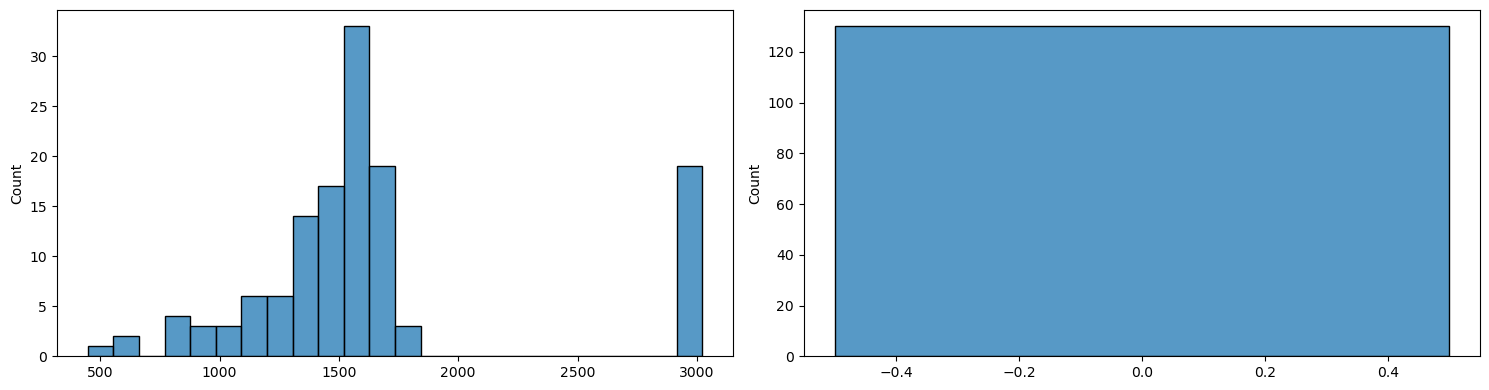

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

ax, fig = plt.subplots(1,2,figsize=(15,4))
sns.histplot(max_values, ax=fig[0])
sns.histplot(min_values, ax=fig[1])
plt.tight_layout()

In [33]:
import glob

files = glob.glob(folder_path+)
#df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
files

['../data/']

In [34]:
df

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,0,1,2,3,4,5,...,3014,3015,3016,3017,3018,3019,3020,3021,3022,3023
0,1680092958165,1680092958165,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1680092958174,1680092958170,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1680092958187,1680092958185,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1680092958199,1680092958195,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1680092958208,1680092958205,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,1680093037847,1680093037845,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,1680093037860,1680093037860,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
74,1680093037873,1680093037870,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
75,1680093037887,1680093037885,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
d = {'DT': 'Dynamic Tripod', 
     'DQ': 'Dynamic Quadrupod', 
     'LT': 'Lateral Tripod', 
     'LQ': 'Lateral Quadrupod',
     'UP': 'Native'}